# Assignment 2: Recreate a Paper
## Sharp transition towards shared vocabularies in multi-agent systems

In [59]:
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import itertools # use this if needed
import string

sns.set_style('darkgrid')


In [60]:
WORD_LENGTH = 5

In [61]:
class PlayerAgent(mesa.Agent):
    def __init__(self, model: mesa.Model, *args, **kwargs) -> None:
        super().__init__(model, *args, **kwargs)

        self.vocabulary = dict()

    def generate_new_word(self):
        new_word = "".join(random.choices(string.ascii_letters, k=WORD_LENGTH))

        return new_word

    def speak(self,context):
        current_object = random.choice(context)
        if current_object not in self.vocabulary:
            new_word = self.generate_new_word()
            self.vocabulary[current_object] = [new_word]
            self.model._add_word(new_word,current_object)
            return (current_object, new_word)
        else:
            return (current_object, random.choice(self.vocabulary[current_object]))

    def hear(self,word,current_object):
        #If the agent doesn't have any words in the vocabulary associated with the object
        if current_object not in self.vocabulary:
            self.vocabulary[current_object] = [word]
            self.model._add_word(word,current_object)
            return False
        #If the agent already has words in its vocabulary for the object, but none of them match
        elif word not in self.vocabulary[current_object]:
            self.vocabulary[current_object].append(word)
            self.model._add_word(word,current_object)
            return False
        # If one of the words in the vocabulary matches the heard word
        else:
            # On success, the agent's vocabulary for this object shrinks to the single successful word.
            old_vocab_for_obj = self.vocabulary[current_object]
            self.vocabulary[current_object] = [word]
            # Notify the model to remove the now-unused words.
            for w in old_vocab_for_obj:
                if w != word:
                    self.model._remove_word(w,current_object)
            return True

In [62]:
class Object():
    pass

class NamingGame(mesa.Model):
    def __init__(self, n_players: int, n_rounds: int, n_objects: int = 1):
        """This implements the naming game with a variable number of agents, rounds and objects to name"""
        super().__init__()
        self.n_agents = n_players
        self.n_rounds = n_rounds
        self.n_objects = n_objects
        self.objects = []
        self.interaction_results = None

        # Performance optimization: track word counts in the model
        self.total_words = 0
        self.word_frequencies = {}

        for _ in range(n_objects):
            self.objects.append(Object())

        for _ in range(self.n_agents):
          PlayerAgent(self)

        self.datacollector = mesa.DataCollector(
            {
                "all_words": lambda m: m.total_words,
                "unique_words": lambda m: len(m.word_frequencies),
                "success": self.get_interaction_results
            }
        )

    def _add_word(self, word, current_object):
        self.total_words += 1
        self.word_frequencies[(word,current_object)] = self.word_frequencies.get((word,current_object), 0) + 1

    def _remove_word(self, word, current_object):
        self.total_words -= 1
        self.word_frequencies[(word,current_object)] -= 1
        if self.word_frequencies[(word,current_object)] == 0:
            del self.word_frequencies[(word,current_object)]

    def step(self):
        self.agents.shuffle(inplace=True)
        speaker, hearer = self.agents.select(at_most=2)
        # print(f"Speaker vocab: {speaker.vocabulary}")
        # print(f"Hearer vocab: {hearer.vocabulary}")
        curr_object, word = speaker.speak(self.objects)
        # print(f"Speaker vocab after speaking: {speaker.vocabulary}")
        success = hearer.hear(word, curr_object)
        # print(f"Hearer vocab after hearing: {hearer.vocabulary}")
        # print("----------------------------------------------")
        if success:
            old_speaker_vocab = speaker.vocabulary[curr_object]
            speaker.vocabulary[curr_object] = [word]
            for w in old_speaker_vocab:
                if w != word:
                    self._remove_word(w,curr_object)


        self.interaction_results = success
        self.datacollector.collect(self)

        #Logic to turn off at convergence
        if (len(self.word_frequencies) == self.n_objects) and (self.total_words == self.n_objects * self.n_agents):
            self.running = False

    def get_interaction_results(self):
        return self.interaction_results

In [63]:
model = NamingGame(1000, None, 1)
model.run_model()

In [64]:
data = model.datacollector.get_model_vars_dataframe()

In [65]:
data['success'].mean()

np.float64(0.24955743857247387)

<Axes: ylabel='unique_words'>

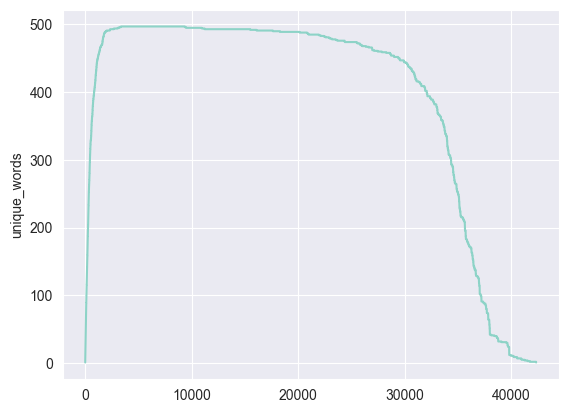

In [66]:
sns.lineplot(data['unique_words'])

<Axes: ylabel='all_words'>

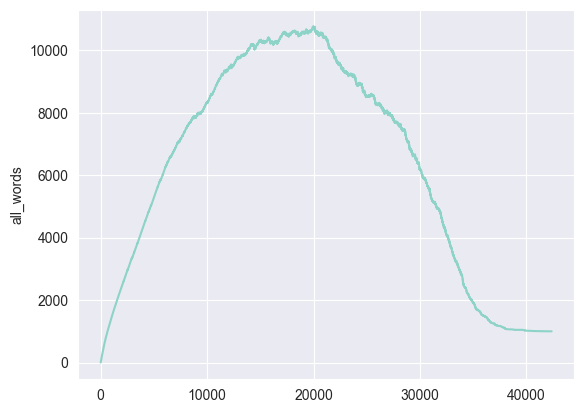

In [67]:
sns.lineplot(data['all_words'])

# Recreating fig 2

In [72]:
N_AGENTS = 1000
N_RUNS = 2000
N_OBJECTS = 1

def run_multiple_times(n_runs = N_RUNS,n_agents = N_AGENTS, n_objects = N_OBJECTS):
    print("Computing single run...")
    single_model = NamingGame(n_agents, None, n_objects)
    single_model.run_model()
    single_data = single_model.datacollector.get_model_vars_dataframe()

    print(f"Computing {n_runs} runs for the ensemble average...")
    all_runs_data = []
    max_steps = 0

    for i in range(n_runs):
        m = NamingGame(n_agents, None, n_objects)
        m.run_model()
        df = m.datacollector.get_model_vars_dataframe()
        all_runs_data.append(df)
        if len(df) > max_steps:
            max_steps = len(df)
    return (single_data, all_runs_data, max_steps)

single_data, all_runs_data, max_steps = run_multiple_times(N_RUNS)

Computing single run...
Computing 2000 runs for the ensemble average...


In [73]:
def count_averages(all_runs_data, max_steps, n_runs = N_RUNS, n_objects = N_OBJECTS, n_agents = N_AGENTS):
    #align for averages
    nw_matrix = np.zeros((n_runs, max_steps))
    nd_matrix = np.zeros((n_runs, max_steps))
    s_matrix = np.zeros((n_runs, max_steps))

    for i, df in enumerate(all_runs_data):
        steps = len(df)
        # Total Words
        nw_matrix[i, :steps] = df['all_words'].values
        nw_matrix[i, steps:] = n_objects * n_agents

        # Unique Words
        nd_matrix[i, :steps] = df['unique_words'].values
        nd_matrix[i, steps:] = n_objects

        # Success Rate
        s_matrix[i, :steps] = df['success'].values
        s_matrix[i, steps:] = 1.0

    # Compute mean across all runs for each time step t
    avg_nw = np.mean(nw_matrix, axis=0)
    avg_nd = np.mean(nd_matrix, axis=0)
    avg_s = pd.Series(np.mean(s_matrix, axis=0))
    return (avg_nw, avg_nd, avg_s)

avg_nw , avg_nd ,avg_s = count_averages(all_runs_data, max_steps)

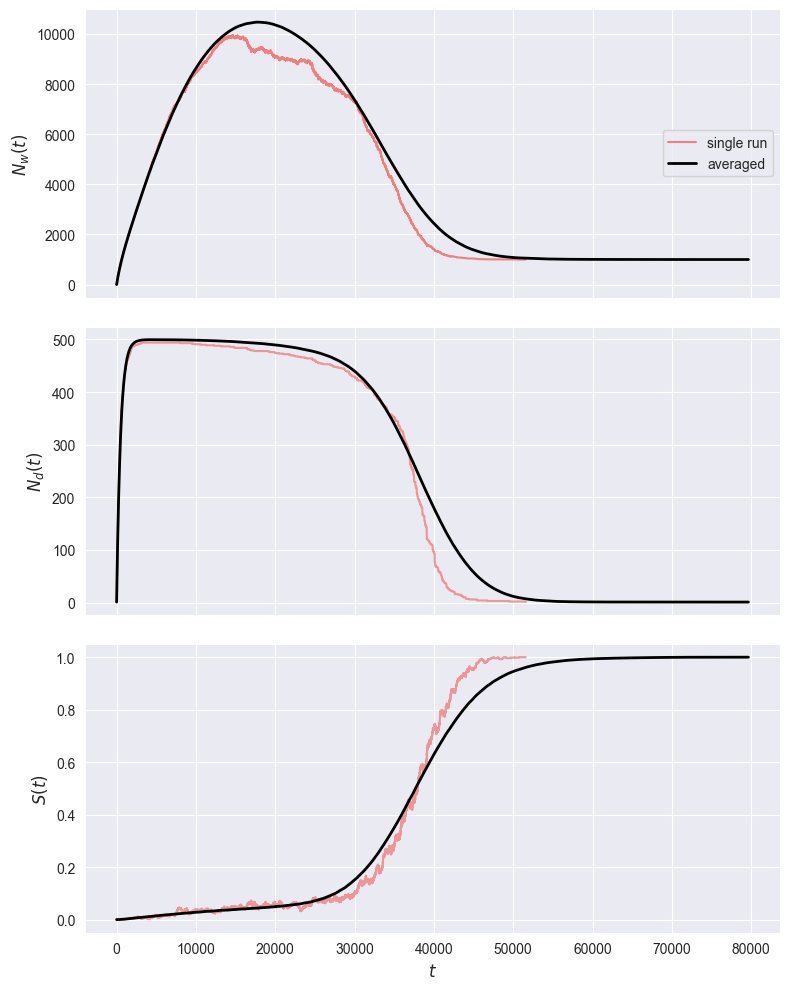

In [74]:

def plot_fig_two(single_data, avg_nw, avg_nd, avg_s):
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    axes[0].plot(single_data['all_words'], color='lightcoral', label='single run')
    axes[0].plot(avg_nw, color='black', linewidth=2, label='averaged')
    axes[0].set_ylabel('$N_w(t)$', fontsize=12)
    axes[0].legend(loc='center right')

    axes[1].plot(single_data['unique_words'], color='lightcoral', alpha=0.8)
    axes[1].plot(avg_nd, color='black', linewidth=2)
    axes[1].set_ylabel('$N_d(t)$', fontsize=12)


    # apply a rolling window here
    single_s_rolling = single_data['success'].rolling(window=500, min_periods=1).mean()
    axes[2].plot(single_s_rolling, color='lightcoral', alpha=0.8)
    axes[2].plot(avg_s.rolling(window=500, min_periods=1).mean(), color='black', linewidth=2)
    axes[2].set_ylabel('$S(t)$', fontsize=12)
    axes[2].set_xlabel('$t$', fontsize=12)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.1)
    plt.show()

plot_fig_two(single_data, avg_nw, avg_nd, avg_s)